## analyzing dispersal weight modeling

In [3]:
from dispersal_weight_generator import *
dispgen = dispersal_weight_generator()
weights_collection = []
topk_w_collection = []
K = 3
C_collection = []
for i in range(3,11,1): # npatch 
    weights_perpatch = []
    incoming_ws_perpatch = []
    C_perpatch = []
    for j in range(100): # sample siz
        sample = dispgen.uniform_dist(i, normalization=2)
        # calculte top k weights and connectivity
        incoming_ws_persample = []
        connectivity_persample = []
        for k in range(sample.shape[0]):
            incoming_w = sample[:,k].copy()
            incoming_w[k] = 0
            topk = np.sort(incoming_w)[-K:]          # K largest
            incoming_ws_persample.append(topk)
            connectivity = np.sum(incoming_w)
            connectivity_persample.append(connectivity)
        incoming_ws_persample = np.concatenate(np.array(incoming_ws_persample))
        connectivity_persample = np.array(connectivity_persample)

        # sample is a diagonally symetric matrix get above diagonals only as an array
        upper_triangular = np.triu(sample, k=1)
        weights = upper_triangular[upper_triangular != 0]
        weights_perpatch.append(weights)
        incoming_ws_perpatch.append(incoming_ws_persample)
        C_perpatch.append(connectivity_persample)
    weights_collection.append(np.concatenate(np.array(weights_perpatch)))
    topk_w_collection.append(np.concatenate(np.array(incoming_ws_perpatch)))
    C_collection.append(np.concatenate(np.array(C_perpatch)))



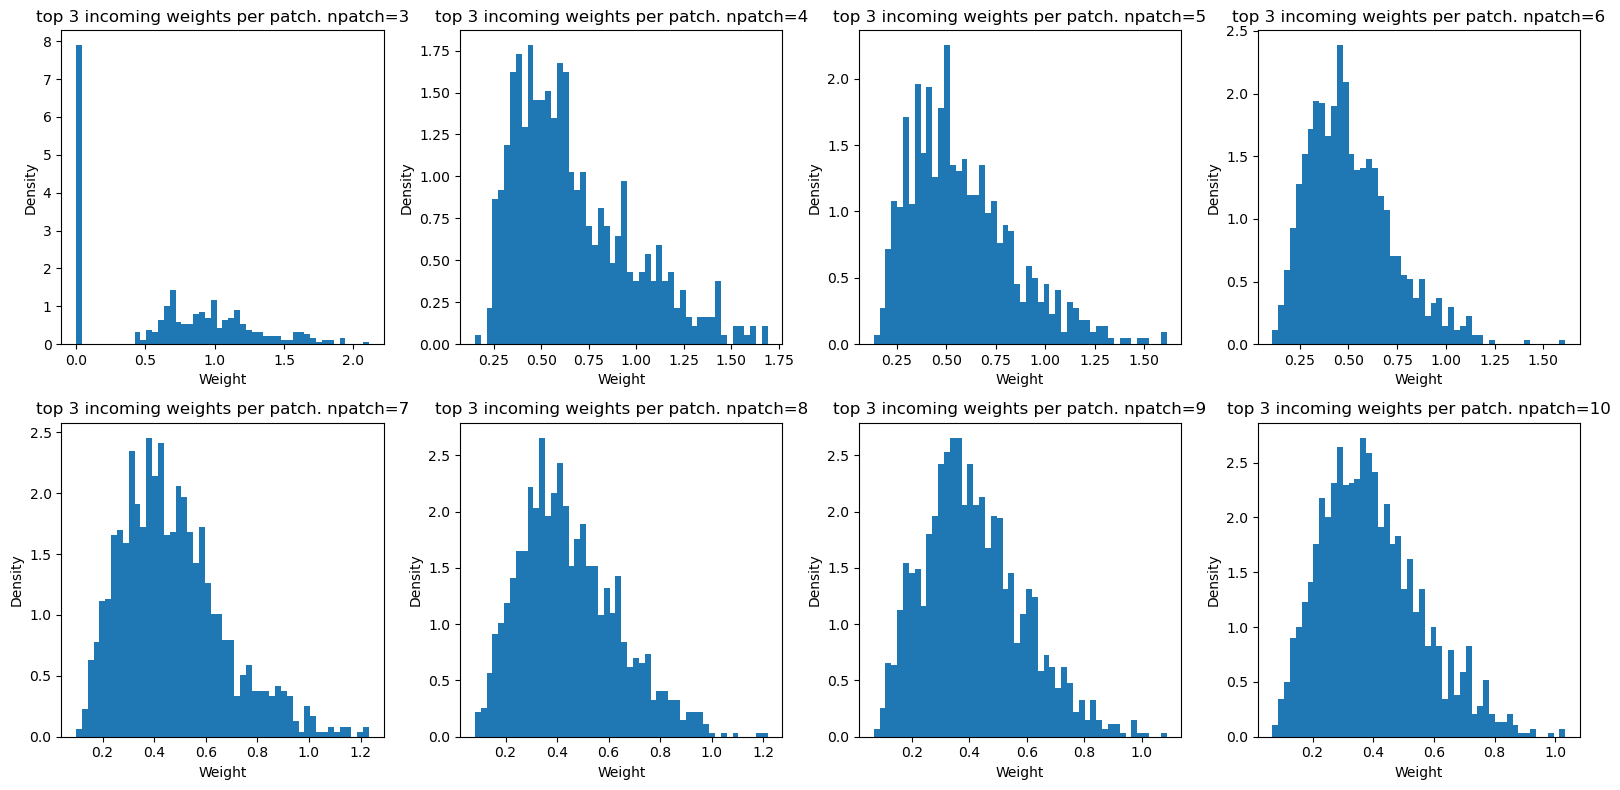

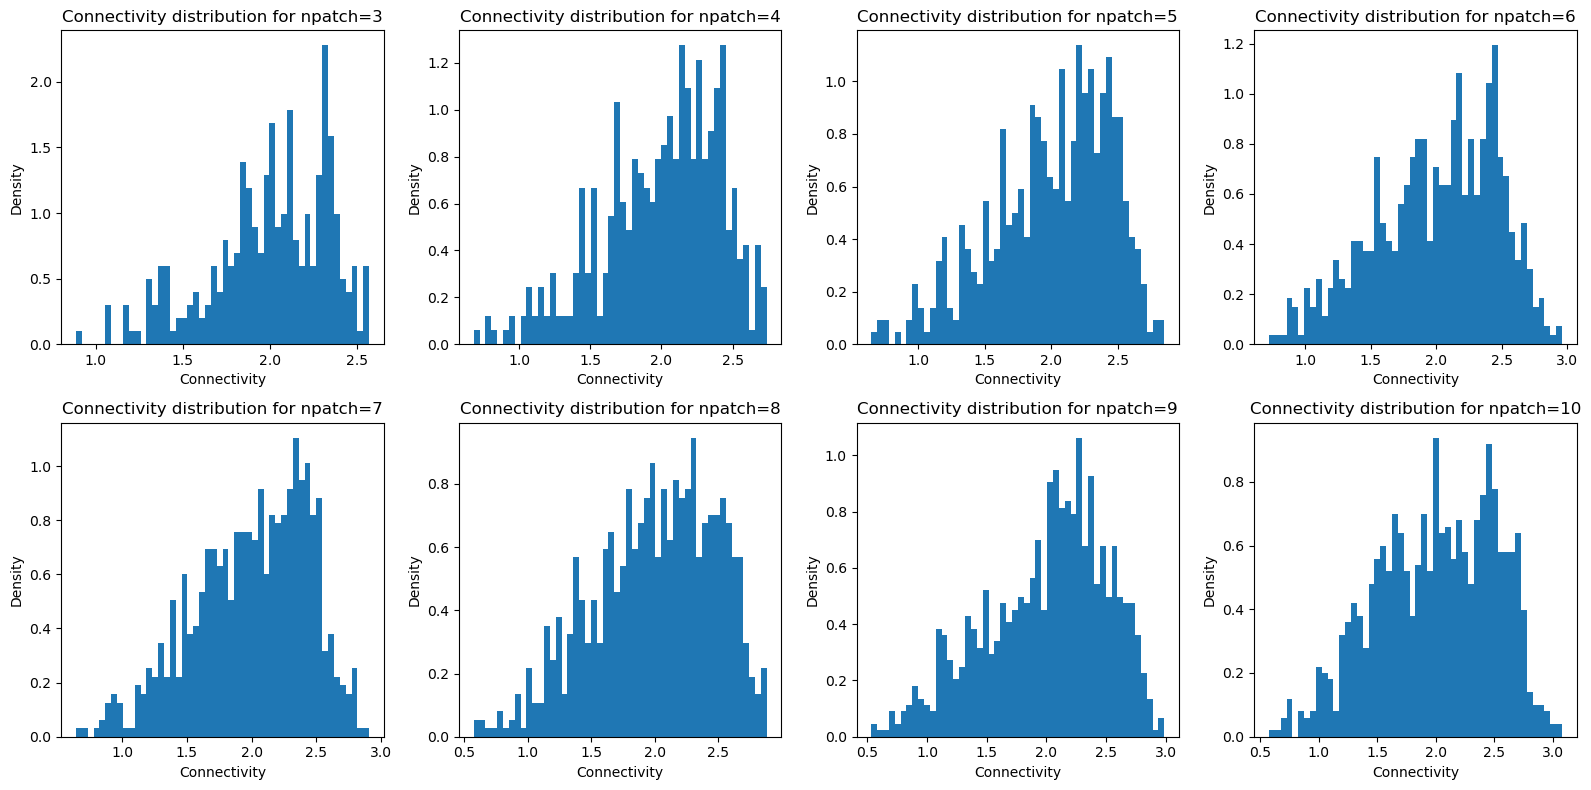

In [2]:
import matplotlib.pyplot as plt
# plot the distribution of top 3 incoming weights per patch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(topk_w_collection)):
    ax = axes[i]
    ax.hist(topk_w_collection[i], bins=50, density=True)
    ax.set_title(f'top 3 incoming weights per patch. npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(topk_w_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
# plot the distribution of connectivity in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(C_collection)):
    ax = axes[i]
    ax.hist(C_collection[i], bins=50, density=True)
    ax.set_title(f'Connectivity distribution for npatch={i+3}')
    ax.set_xlabel('Connectivity')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(C_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

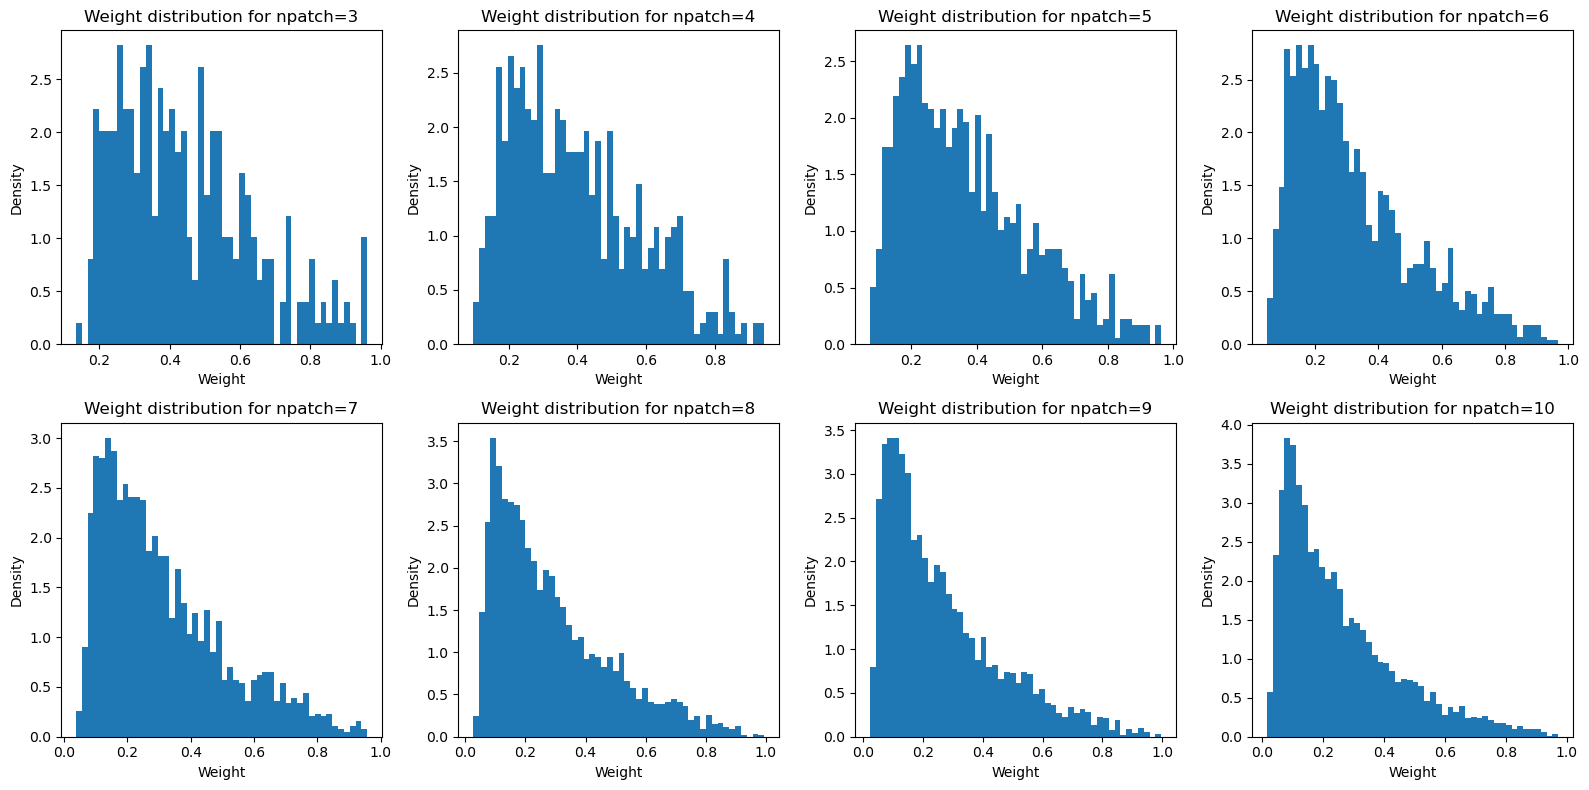

In [ ]:
import matplotlib.pyplot as plt
# plot the distribution of weights for each npatch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(weights_collection)):
    ax = axes[i]
    ax.hist(weights_collection[i], bins=50, density=True)
    ax.set_title(f'Weight distribution for npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(weights_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

